Answers for Week 4

* Name: Oberon Moens
* Username: opmoens
* Student s-number: s4508602
* Group: AS1

In [25]:
#4.1
x = [1,2,3,10]
y = [10, 20, 30, 40]

print([x + y for x,y in zip(x,y)])

def add(x,y):
    return x+y

print(list(map(add,x,y)))

[11, 22, 33, 50]
[11, 22, 33, 50]


In [42]:
#4.3
import numpy as np
hand = str(input("Wanna play a little game?! Rock(R), Paper(P), Scissors(S):"))

Hands = ['R', 'P', 'S']
Saw = np.random.choice(Hands)

print(f"You played {hand} and Saw played {Saw}")

if hand == Saw:
    print("Its a tie")
elif (hand == 'R' and Saw == 'S') or (hand == 'P' and Saw == 'R') or (hand == 'S' and Saw == 'P'):
    print("CONGRACHULASJONS! U WON!")
else: 
    print("COMPUTER WILL SELF DESTRUCT IN 5...4...3...2..1...")

Wanna play a little game?! Rock(R), Paper(P), Scissors(S):P
You played P and Saw played S
COMPUTER WILL SELF DESTRUCT IN 5...4...3...2..1...


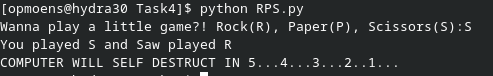

P(X ≤ 193) = 0.8407
P(within 1 std dev) = 0.6827


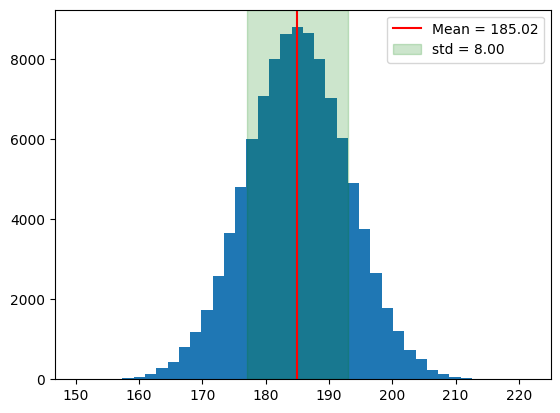

In [58]:
#4.4
import numpy as np, matplotlib.pyplot as plt
from scipy.stats import norm

height = np.random.normal(185,8,100000)

mean = np.average(height)
stddev = np.std(height)

h = 193

probLessEqualH = norm.cdf(h, loc=mean, scale=stddev)

print(f"P(X ≤ {h}) = {probLessEqualH:.4f}")

probWithin1Std = norm.cdf(mean + stddev, loc=mean, scale=stddev) - norm.cdf(mean - stddev, loc=mean, scale=stddev)

print(f"P(within 1 std dev) = {probWithin1Std:.4f}")

plt.hist(height, bins=40)
plt.axvline(mean, color='Red', label=f'Mean = {mean:.2f}')
plt.axvspan(mean-stddev, mean+stddev, alpha=0.2, color='Green', label=f'std = {stddev:.2f}')
plt.legend()
plt.show()

In [60]:
#4.6
import numpy as np

func = input("Input a function:")
lowerBound = float(input("Input the lower bound:"))
upperBound = float(input("Input the upper bound:"))

def integral(func, lowerBound, upperBound):
    x = np.random.uniform(lowerBound, upperBound, 100000)
    
    # Evaluate function (vectorized)
    y = eval(func)
    
    # Monte Carlo estimate
    result = (upperBound - lowerBound) * np.mean(y)
    
    return result

result = integral(func, lowerBound, upperBound)

print(f"Estimated integral = {result}")

Input a function:x**2
Input the lower bound:0
Input the upper bound:1
Estimated integral = 0.3321847370745564


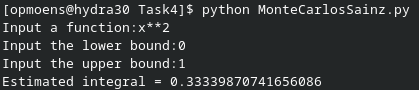

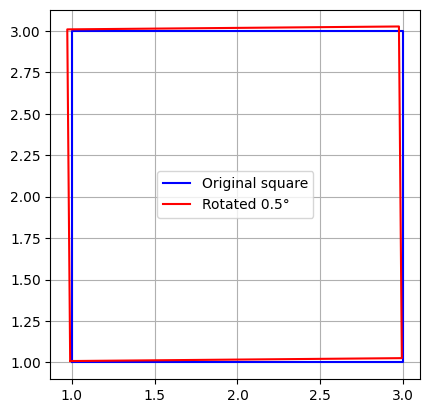

In [18]:
#4.12
import numpy as np
import matplotlib.pyplot as plt

# Square coordinates
x = np.array([1,3,3,1,1])
y = np.array([1,1,3,3,1])

# Convert to complex numbers
z = x + 1j*y

# Rotation angle (degrees)
angle = 0.5  # change this value

# Convert to radians
theta = np.deg2rad(angle)

# Complex rotor
rotor = np.exp(1j * theta)

# Rotate
z_rot = z * rotor

# Extract rotated coordinates
x_rot = np.real(z_rot)
y_rot = np.imag(z_rot)

# Plot original square
plt.plot(x, y, 'b', label='Original square')

# Plot rotated square
plt.plot(x_rot, y_rot, 'r', label=f'Rotated {angle}°')

plt.gca().set_aspect('equal')
plt.grid()
plt.legend()
plt.show()

In [63]:
#4.14
import numpy as np

def funcfilter(func, seq):
    # Convert input to numpy array (supports single number, list, tuple, ndarray)
    arr = np.asarray(seq)
    
    # Filter strictly positive values
    filtered = arr[arr > 0]
    
    # Apply function
    result = func(filtered)
    
    return result

sq = np.array([-100, -10, 0, 10, 100])
result = funcfilter(np.log10, sq)
print("Result log10:", result)

result_single = funcfilter(np.log10, 100)
print("Result single:", result_single)

Result log10: [1. 2.]
Result single: [2.]


In [20]:
#4.16
import numpy as np
from scipy.integrate import quad
from astropy.cosmology import Planck18
from astropy import constants as const

H0 = Planck18.H0.value          
Om0 = Planck18.Om0              
Ode0 = Planck18.Ode0            

H0_SI = H0 / (3.085677581e19)  

def H_z(z):
    return H0_SI * np.sqrt(Om0 * (1 + z)**3 + Ode0)

def integrand(z):
    return 1.0 / ((1.0 + z) * H_z(z))

# Lookback time function
def lookback_time(z):
    integral, error = quad(integrand, 0, z)
    return integral  # in seconds

# Convert seconds to Gyr
seconds_in_Gyr = 3.15576e16  # seconds in 1 Gyr

z = 2.0 #change this value
tL_seconds = lookback_time(z)
tL_Gyr = tL_seconds / seconds_in_Gyr

print(f"Lookback time at z = {z}: {tL_Gyr:.2f} Gyr")

Lookback time at z = 2.0: 10.53 Gyr


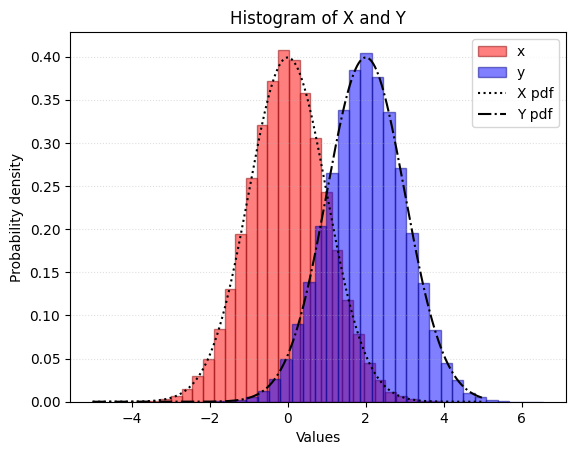

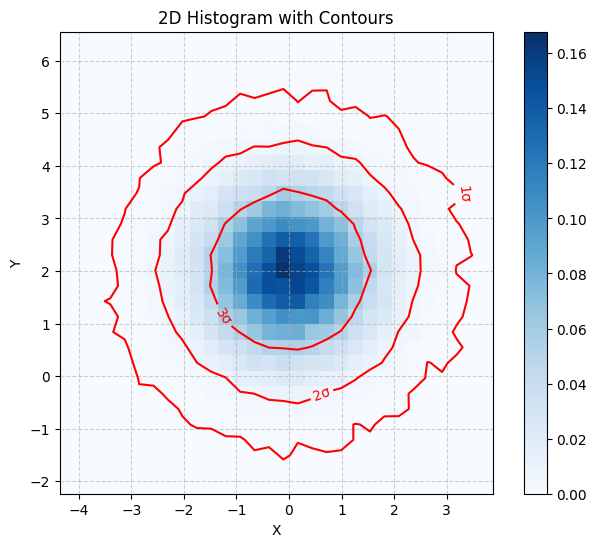

In [107]:
#4.21
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, chi2


X = np.random.normal(0.0, 1.0, 100000)
Y = np.random.normal(2.0, 1.0, 100000)

bins = 30

plt.hist(X, bins, density=True, alpha=0.5, edgecolor = 'darkred', color = 'red', label='x')
plt.hist(Y, bins, density=True, alpha=0.5, edgecolor = 'darkblue', color = 'blue', label='y')

plt.plot(Values, Xpdf, color='black', linestyle=':', label="X pdf")
plt.plot(Values, Ypdf, color='black', linestyle='-.', label="Y pdf")

plt.title("Histogram of X and Y")
plt.xlabel("Values")
plt.ylabel("Probability density")
plt.legend(loc='upper right')
plt.grid(alpha=0.4, linestyle=':', axis='y')
plt.show()

counts, xedges, yedges = np.histogram2d(X, Y, bins, density=True)
Xg, Yg = np.meshgrid((xedges[1:]+xedges[:-1])/2, (yedges[1:]+yedges[:-1])/2)

levels = []
for p in [0.68, 0.95, 0.997]:
    levels.append(Zsorted[np.searchsorted(cumsum, p)])

levels = sorted(levels)

plt.figure(figsize=(8,6))
plt.hist2d(X, Y, bins, cmap='Blues', density=True)
plt.colorbar()

contour = plt.contour(Xg, Yg, counts.T, levels=levels, colors='red')
plt.clabel(contour, fmt={levels[0]:'1σ', levels[1]:'2σ', levels[2]:'3σ'}, inline=True, fontsize=10)
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(alpha=0.6, linestyle='--')
plt.title("2D Histogram with Contours")
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

ValueError: Contour levels must be increasing

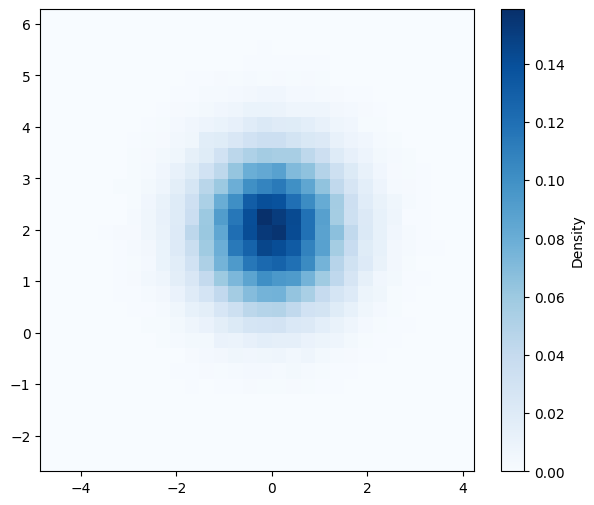